# Predicting Using Machine Learning
This notebook looks into using various Python-Based Machine Learning and Data Science libraries is an attempt to build a Machine Learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

#### We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experiments

---

# Preparing the tools

In [48]:
# import all the tools that we need

# Regular EDA (Exploratory and Analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model from scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Load The Data

In [49]:
# Loading the data
df = pd.read_csv('practice/heart-disease.csv')

---

# Data Exploration (Exploratory Data Analysis or EDA)
* Problem definition
* Data
* Evaluation
* Features

The goal here is to find out more about the data and become a subject matter export on the dataset you're working with.
1. What question are we trying to solve?
2. What kind of data do we have and how do we treat different types?
3. what's missing from the data and how do you deal with it?
4. Where are the outliers and why should we care about them?
5. How can you add, change or remove features to get more out of your data?

In [50]:
df.shape

(303, 14)

In [51]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [52]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
33,54,1,2,125,273,0,0,152,0,0.5,0,1,2,1
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2,1
49,53,0,0,138,234,0,0,160,0,0.0,2,0,2,1
57,45,1,0,115,260,0,0,185,0,0.0,2,0,2,1


In [53]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [54]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [55]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [56]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [57]:
df.isna().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# Data Visualization

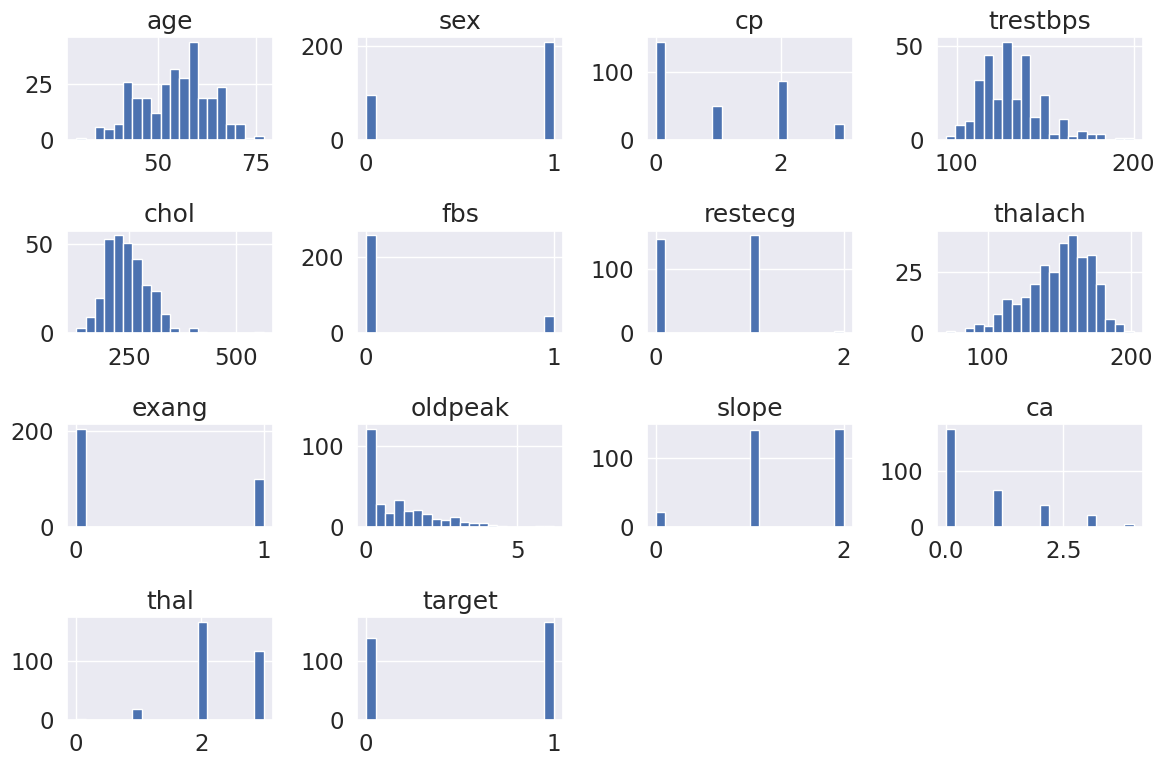

In [60]:
# plotting histogram for the entier dataset
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()

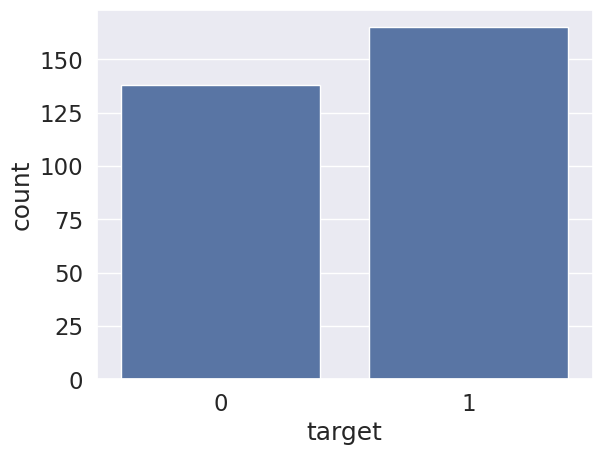

In [61]:
# Visualization to check if the dataset is balanced or not
g = sns.countplot(x = 'target', data = df)
plt.xlabel("target")
plt.ylabel("count");

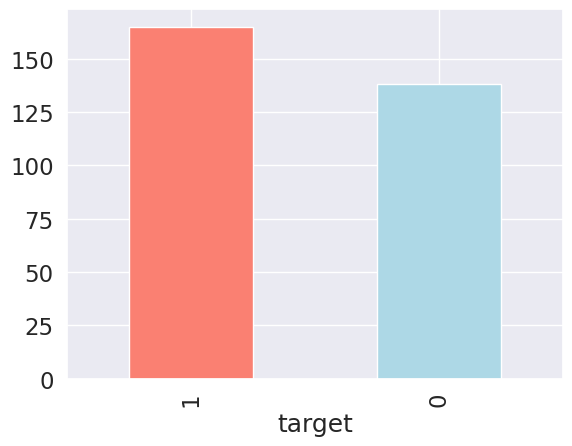

In [62]:
# let's find out how many of each class there
df["target"].value_counts().plot(
    kind = "bar",
    color = ["salmon", "lightblue"]
);

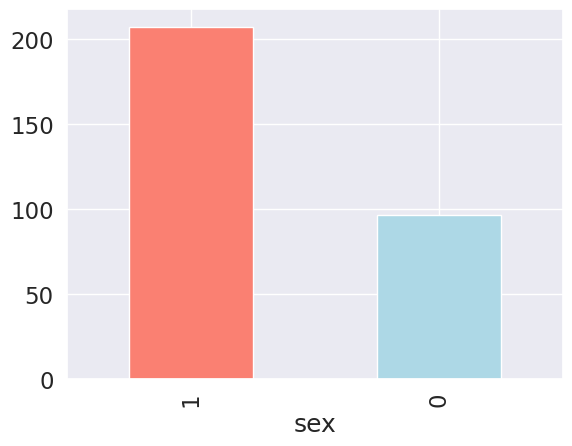

In [63]:
# let's find out how many sex we have
df["sex"].value_counts().plot(
    kind = "bar",
    color = ["salmon", "lightblue"]
);

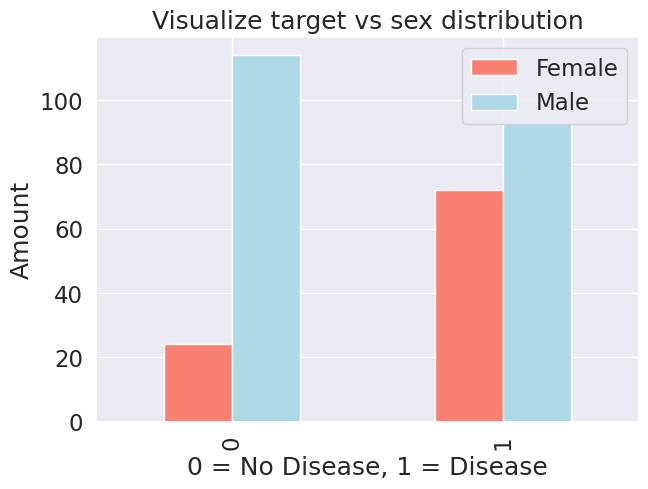

In [64]:
# Compare target column with sex column and create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind = "bar",
                                    figsize = (7, 5),
                                    color = ["salmon", "lightblue"])
plt.title("Visualize target vs sex distribution")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);

# Feature Engineering

### Feature Selection

In [65]:
# Get correlation of all the features of the dataset
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


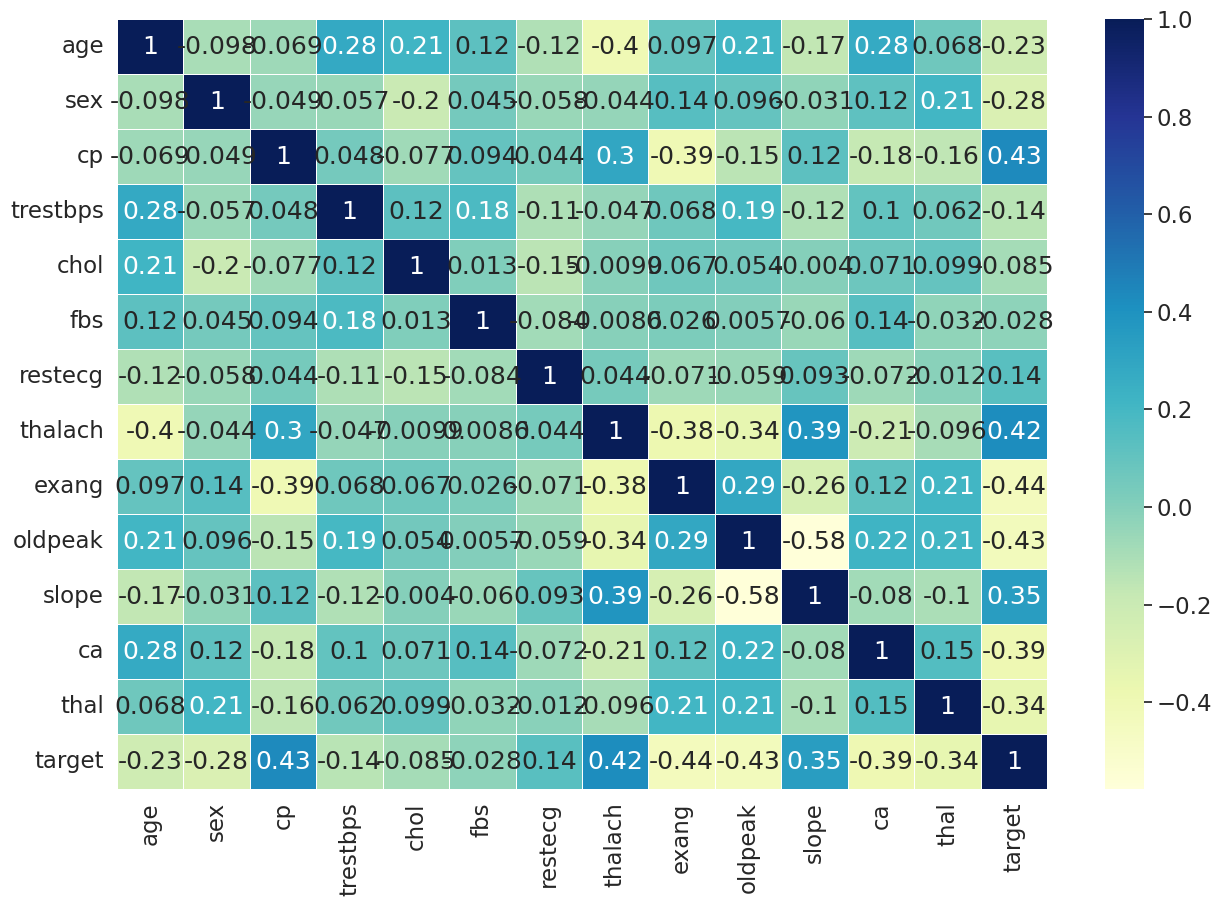

In [66]:
# selecting correlated features using heatmap
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(corr_matrix,
                 annot = True,
                 linewidths = 0.5,
                 cmap = "YlGnBu")

# Data Preprocessing

### Handling categorical features
after exploring the dataset, I observed that converting the categorical variables into dummy variables using `get_dummies`. Though we don't have any strings in our dataset it is necessary to convert ('sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal') these features.

*Example: Consider the 'sex' column, it is a binary feature which has 0's and 1's as its values. Keeping it as it is would lead the algorithm to think 0 is lower value and 1 is a higher value, which should not be the case since the gender cannot be ordinal feature.*

In [67]:
dataset = pd.get_dummies(df, columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"])

## Feature Scaling

In [68]:
dataset.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_0',
       'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0',
       'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1',
       'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1',
       'thal_2', 'thal_3'],
      dtype='str')

In [69]:
standScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standScaler.fit_transform(dataset[columns_to_scale])

In [70]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,True,False,False,True,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,False,True,False,True,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,True,False,True,False,...,True,True,False,False,False,False,False,False,True,False


In [71]:
# Splitting dataset into dependent and independent features
X = dataset.drop("target", axis = 1)
y = dataset["target"]

In [72]:
X

,age,trestbps,chol,thalach,oldpeak,sex_0,sex_1,cp_0,cp_1,cp_2,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,False,True,False,False,False,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,False,True,False,False,True,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,True,False,False,True,False,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,False,True,False,True,False,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,True,False,True,False,False,...,True,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.290464,0.478391,-0.101730,-1.165281,-0.724323,True,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
299,-1.033002,-1.234996,0.342756,-0.771706,0.138373,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
300,1.503641,0.706843,-1.029353,-0.378132,2.036303,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,True
301,0.290464,-0.092738,-2.227533,-1.515125,0.138373,False,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True


In [73]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

---

# Model Building
I will be experimenting with 3 algorithms:
1. Random Forest
2. Logistic Regression
3. K-Nearst Neighbors

In [74]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the pattens) on the training set.

and we'll test it (use the pattenrs) on the test set.

## We're going to try 3 different machine learning model:
1. Random Forest
2. Logistic Regression
3. K-Nearest Neighbors

## We gonna use a function

In [75]:
# Put models in a dictionary
models = {
    "Logistic Regression" : LogisticRegression(),
    "Random Forest" : RandomForestClassifier(),
    "KNN" : KNeighborsClassifier()
}

# Create a function to fit and score the models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and Evaluates given machine learning models.
    models: a dict of different machine learning models.
    X_train: Training data (NO Labels)
    X_test: Test data (NO Labels)
    y_train: Training labels
    y_test: Test labels
    """
    # set random seed
    np.random.seed(42)
    # Make a dictionary to keep model scores
    model_scores = {}
    # Loop through model
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_score
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [76]:
model_scores = fit_and_score(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)
model_scores

{'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8688524590163934,
 'KNN': 0.9016393442622951}

# Model Comparison

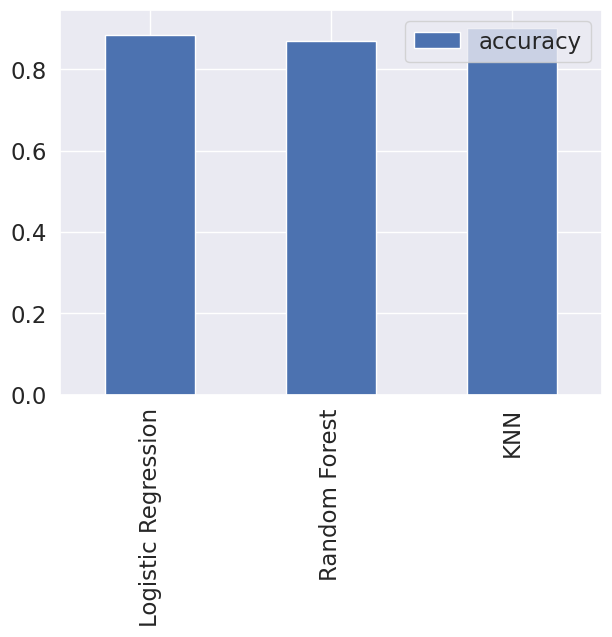

In [77]:
model_comparison = pd.DataFrame(model_scores, index = ['accuracy'])
model_comparison.T.plot.bar(figsize = (7, 5));

The initial accuracy is not the final one — we could improve it further using hyperparameter tuning, but we skip it since current accuracies are already good enough and further tuning is unnecessary.

---

# Evaluating
* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

To Make comparisons and evaluate trained model, first we need to make predictions.

In [78]:
# Instantiate KNN model
knn = KNeighborsClassifier()

# Fit the model
knn.fit(X_train, y_train)

knn.score(X_test, y_test)

0.9016393442622951

In [79]:
# Make prediction
y_preds = knn.predict(X_test)

In [80]:
y_preds

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [81]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

## Confusion Matrix

In [82]:
print(confusion_matrix(y_test, y_preds))

[[26  3]
 [ 3 29]]


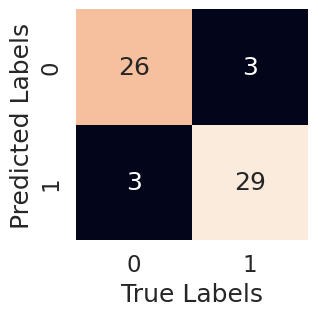

In [83]:
# Make it prettier
sns.set(font_scale = 1.5)

def plot_conf_mat(y_test, y_preds):
    """
    plot a nice looking confusion matrix using seaborn's heatmap()
    """

    fig, ax = plt.subplots(figsize = (3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot = True,
                     cbar = False)
    plt.xlabel("True Labels")
    plt.ylabel("Predicted Labels")
plot_conf_mat(y_test, y_preds)

## Classification reports

In [84]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



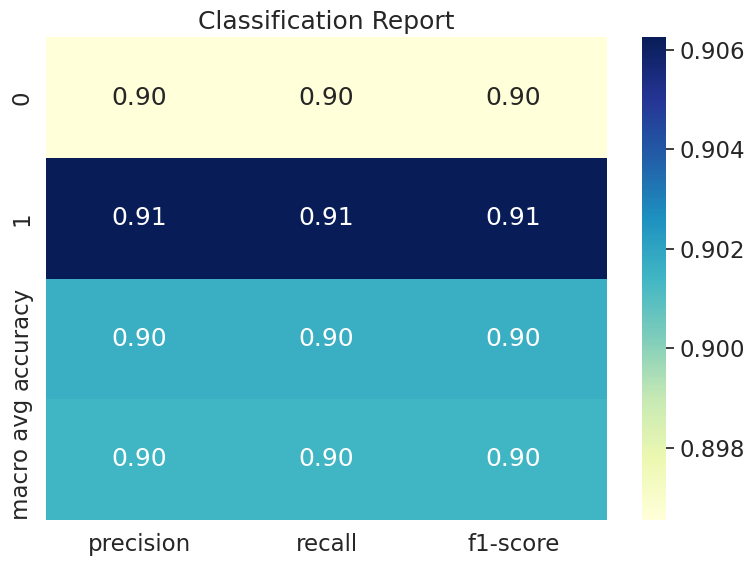

In [85]:
# Make it prettier

# Get classification report as dictionary
report = classification_report(y_test, y_preds, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_df.iloc[:-1, :3], annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Classification Report')
plt.tight_layout()

## Calculate evaluation metrics using cross-validation
We're going to calculate precision, recall and f1-score of our model using cross-validation and to do so we'll be using

## `cross_val_score()`

In [86]:
# Cross-Validated accuracy
cv_acc = cross_val_score(
    knn,
    X,
    y,
    cv = 5,
    scoring = "accuracy"
)

print(cv_acc)
print(np.mean(cv_acc))

[0.80327869 0.91803279 0.80327869 0.86666667 0.76666667]
0.831584699453552


In [87]:
# Cross-Validated precision
cv_precision = cross_val_score(
    knn,
    X,
    y,
    cv = 5,
    scoring = "precision"
)

print(cv_precision)
print(np.mean(cv_acc))

[0.8        0.9375     0.83870968 0.83783784 0.75675676]
0.831584699453552


In [88]:
# Cross-Validated recall
cv_recall = cross_val_score(
    knn,
    X,
    y,
    cv = 5,
    scoring = "recall"
)

print(cv_recall)
print(np.mean(cv_recall))

[0.84848485 0.90909091 0.78787879 0.93939394 0.84848485]
0.8666666666666666


In [89]:
# Cross-Validated f1-score
cv_f1 = cross_val_score(
    knn,
    X,
    y,
    cv = 5,
    scoring = "f1"
)

print(cv_f1)
print(np.mean(cv_f1))

[0.82352941 0.92307692 0.8125     0.88571429 0.8       ]
0.8489641241111829


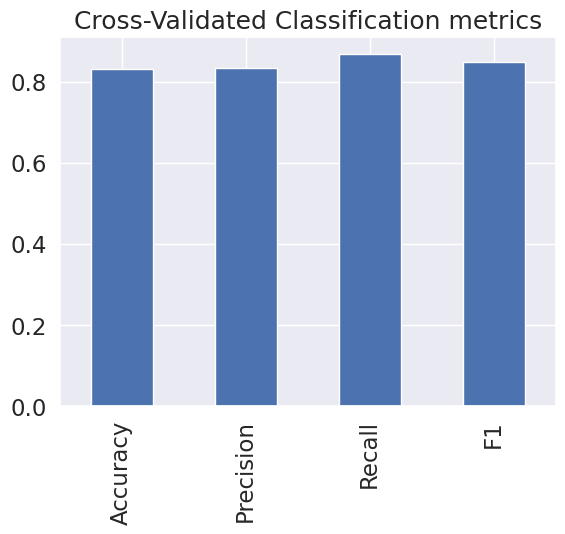

In [90]:
# Cross-Validated metrics
cv_metrics = pd.DataFrame({
    "Accuracy": np.mean(cv_acc),
    "Precision": np.mean(cv_precision),
    "Recall": np.mean(cv_recall),
    "F1": np.mean(cv_f1)
   }, index = [0])

cv_metrics.T.plot.bar(
    title = "Cross-Validated Classification metrics",
    legend = False
);

---

# Feature Importance

      feature  importance
0         age    0.047541
3     thalach    0.045902
28     thal_2    0.034426
4     oldpeak    0.027869
2        chol    0.026230
1    trestbps    0.026230
11      fbs_0    0.022951
13  restecg_0    0.022951
14  restecg_1    0.022951
12      fbs_1    0.022951
29     thal_3    0.022951
21       ca_0    0.019672
7        cp_0    0.016393
19    slope_1    0.014754
17    exang_1    0.014754
16    exang_0    0.014754
20    slope_2    0.013115
5       sex_0    0.009836
6       sex_1    0.009836
22       ca_1    0.008197
8        cp_1    0.004918
23       ca_2    0.003279
25       ca_4    0.000000
10       cp_3    0.000000
18    slope_0    0.000000
15  restecg_2    0.000000
26     thal_0    0.000000
24       ca_3    0.000000
27     thal_1   -0.003279
9        cp_2   -0.014754


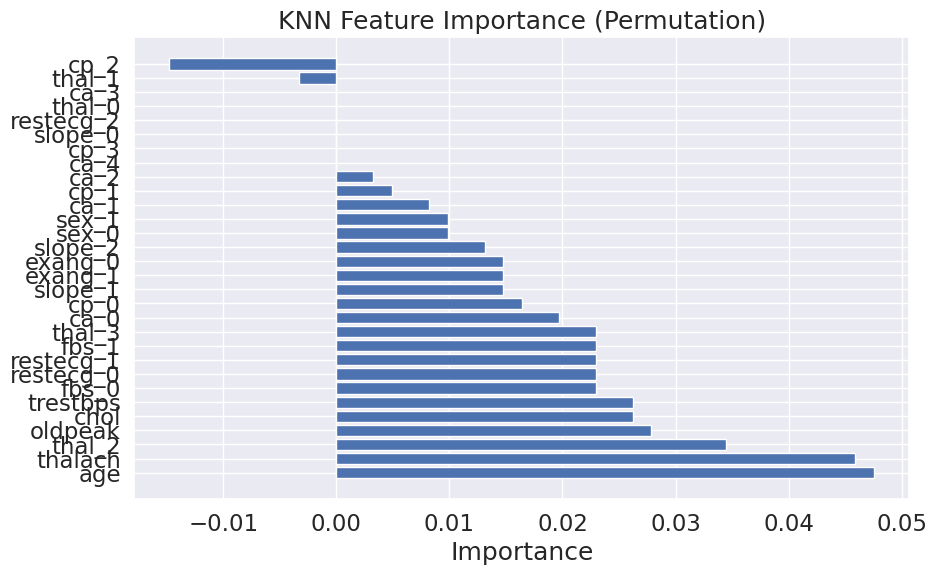

In [91]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

# Print
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('KNN Feature Importance (Permutation)')
plt.show()